In [37]:
import pandas as pd
import numpy as np
from os import listdir
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
def csv_df(mypath, columns):
    mean = pd.read_csv(mypath + '2024-02-04.csv')
    mean['mean'] = mean[columns].mean(axis=1)
    mean.sort_values(by=['mean'], inplace=True, ascending=False)
    mean = mean[['Unnamed: 0', 'mean']].rename(columns={'mean': '2024-02-04'})
    
    for f in os.listdir(mypath)[1:]:
        meanf = pd.read_csv(mypath + f)
        meanf['mean'] = meanf[columns].mean(axis=1)
        meanf = meanf[['Unnamed: 0', 'mean']].rename(columns={'mean': f[:-4]})
        mean = pd.merge(mean, meanf, how='left', on='Unnamed: 0')
    
    mean = mean.T
    mean = mean.rename(columns=mean.loc['Unnamed: 0'])
    mean.drop('Unnamed: 0', axis=0, inplace=True)
    return mean

In [39]:
#['noExperience', 'between1And3', 'between3And6','moreThan6']

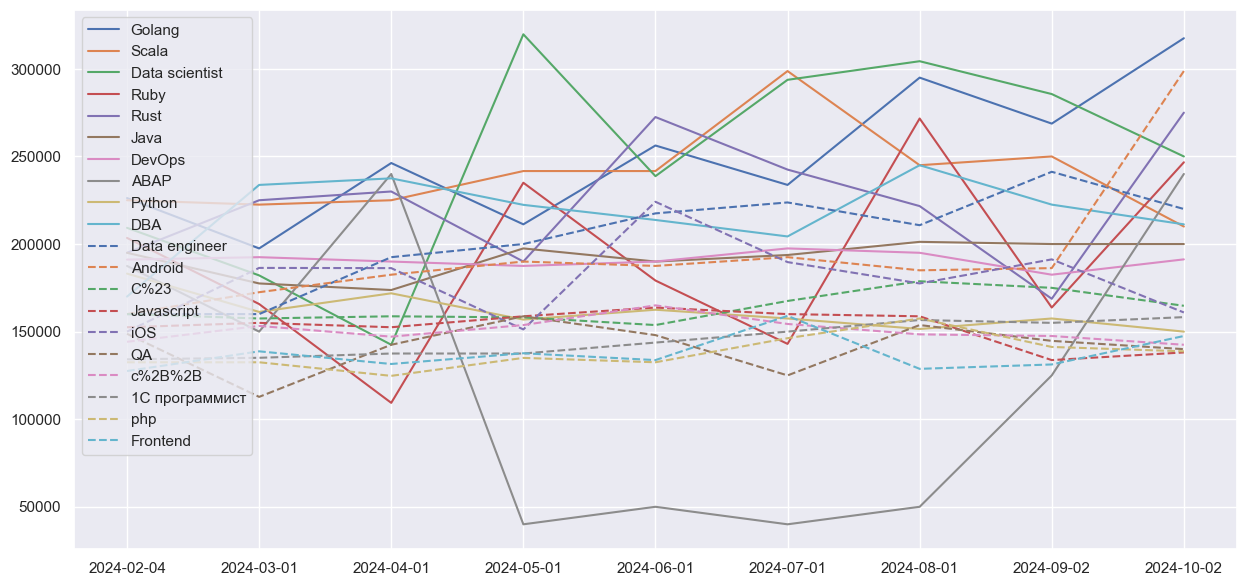

In [40]:
mean1 = csv_df('./langs/', ['noExperience', 'between1And3', 'between3And6','moreThan6']).copy()
colmns = mean1.columns

fig, ax = plt.subplots()
fig.set_size_inches(15, 7)
labels = []

for i in enumerate(colmns):
    if i[0] < 10:
        ax.plot(mean1[i[1]])
        labels.append(mean1[i[1]].name)
        col = i
    elif 20> i[0] >= 10:
        ax.plot(mean1[i[1]], linestyle='--')
        labels.append(mean1[i[1]].name)
    elif i[0] >= 20:
        ax.plot(mean1[i[1]], linestyle=':')
        labels.append(mean1[i[1]].name)

ax.legend(labels, loc=2)

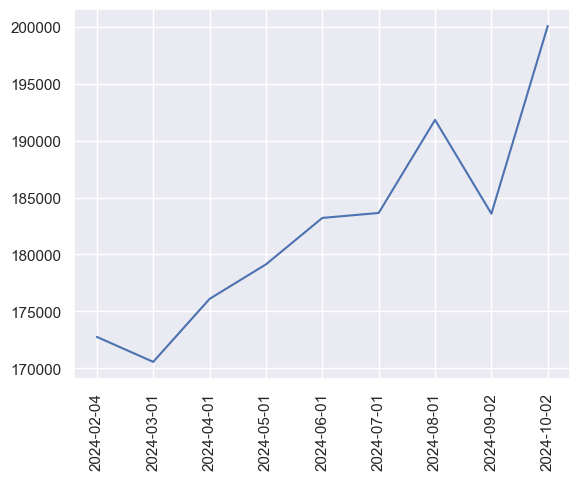

In [41]:
fig, ax = plt.subplots()
plt.plot(mean1.mean(axis=1))
ax.xaxis.set_tick_params(rotation=90)
plt.show()

In [42]:
mean_begin = mean1.iloc[:3].mean()
mean_end = mean1.iloc[-3:].mean()
change1 = ((mean_end - mean_begin)*100/mean_begin).sort_values(ascending=False)

mean2 = csv_df('./langs/', ['noExperience', 'between1And3'])
mean_begin2 = mean2.iloc[:3].mean()
mean_end2 = mean2.iloc[-3:].mean()
change2 = (mean_end2 - mean_begin2)*100/mean_begin2

mean3 = csv_df('./langs/', ['between3And6','moreThan6'])
mean_begin3 = mean3.iloc[:3].mean()
mean_end3 = mean3.iloc[-3:].mean()
change3 = (mean_end3 - mean_begin3)*100/mean_begin3

df = pd.DataFrame({"all": change1})
df = pd.merge(df, change3.rename(">3"), left_index=True, right_index=True)
df = pd.merge(df, change2.rename("<3"), left_index=True, right_index=True)

for i in df.columns:
    df[i] = df[i].astype(float)

<Axes: >

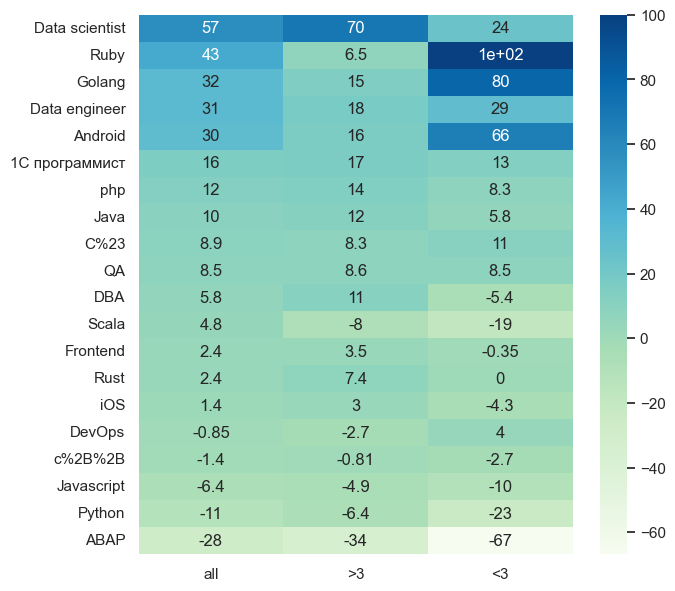

In [43]:
plt.figure(figsize=(7,7))
sns.set(font_scale=1.0)
sns.heatmap(df,cmap='GnBu',annot=True)

In [44]:
df = pd.DataFrame({"change": change1}).rank()
df = pd.merge(df, mean1.mean().rank().rename("mean"), left_index=True, right_index=True)
df["sum_rank"] = df["change"] + df["mean"]
df = df.sort_values(by="sum_rank", ascending=False)

<Axes: >

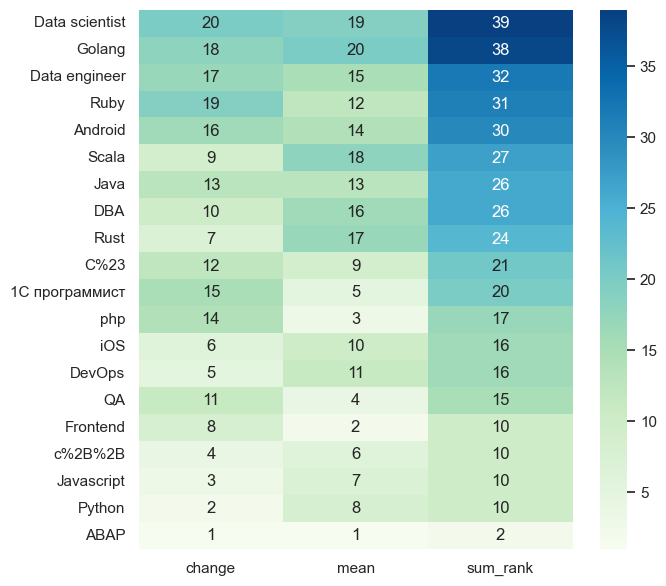

In [45]:
plt.figure(figsize=(7,7))
sns.set(font_scale=1.0)
sns.heatmap(df,cmap='GnBu',annot=True)

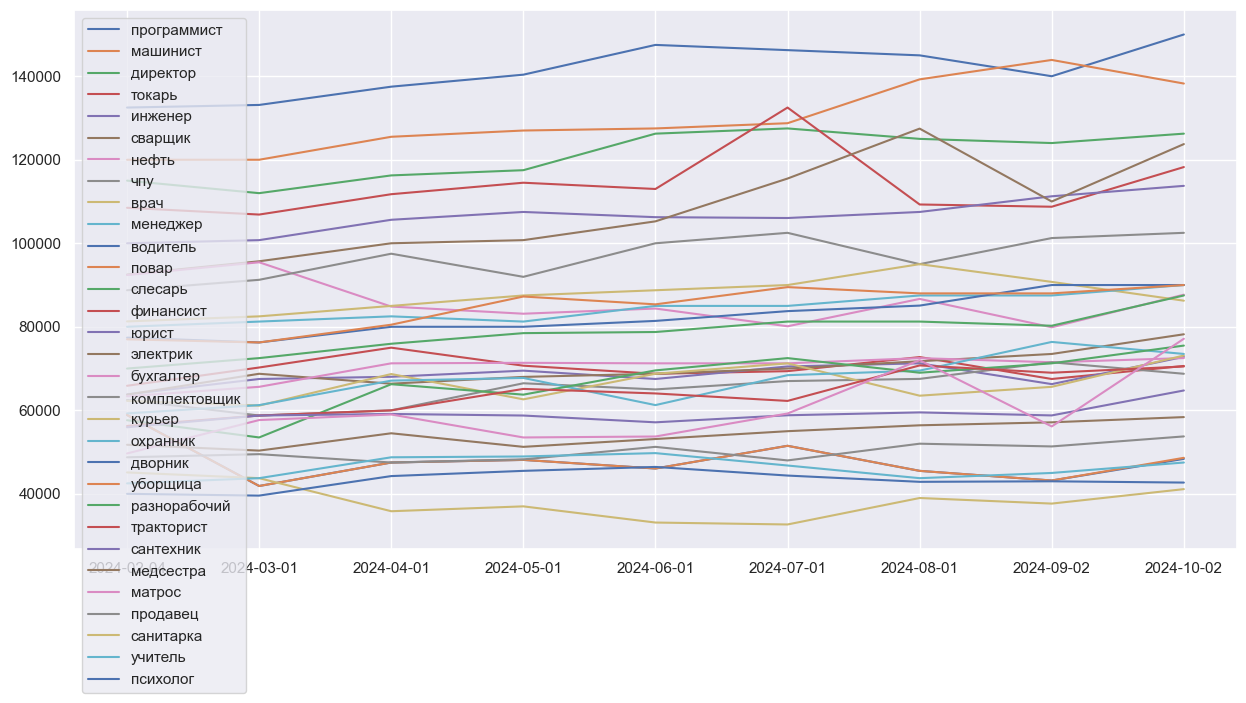

In [46]:
mean1 = csv_df('./profs/', ['noExperience', 'between1And3', 'between3And6','moreThan6']).copy()
colmns = mean1.columns

fig, ax = plt.subplots()
fig.set_size_inches(15, 7)
labels = []
col = ""

for i in colmns:
    if col[:2] != 'DB':
        ax.plot(mean1[i])
        labels.append(mean1[i].name)
        col = i
    else:
        ax.plot(mean1[i], linestyle='--')
        labels.append(mean1[i].name)
        col = 'DB'

ax.legend(labels, loc=2)

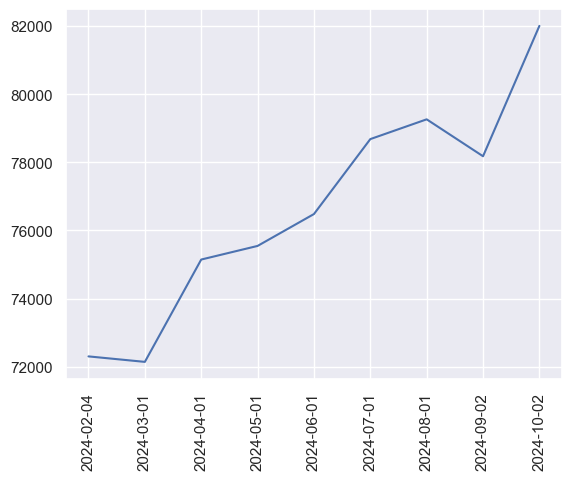

In [47]:
fig, ax = plt.subplots()
plt.plot(mean1.mean(axis=1))
ax.xaxis.set_tick_params(rotation=90)
plt.show()

In [48]:
mean_begin = mean1.iloc[:3].mean()
mean_end = mean1.iloc[-3:].mean()
change1 = ((mean_end - mean_begin)*100/mean_begin).sort_values(ascending=False)

mean2 = csv_df('./profs/', ['noExperience', 'between1And3'])
mean_begin2 = mean2.iloc[:3].mean()
mean_end2 = mean2.iloc[-3:].mean()
change2 = (mean_end2 - mean_begin2)*100/mean_begin2

mean3 = csv_df('./profs/', ['between3And6','moreThan6'])
mean_begin3 = mean3.iloc[:3].mean()
mean_end3 = mean3.iloc[-3:].mean()
change3 = (mean_end3 - mean_begin3)*100/mean_begin3

df = pd.DataFrame({"all": change1})
df = pd.merge(df, change3.rename(">3"), left_index=True, right_index=True)
df = pd.merge(df, change2.rename("<3"), left_index=True, right_index=True)

for i in df.columns:
    df[i] = df[i].astype(float)

<Axes: >

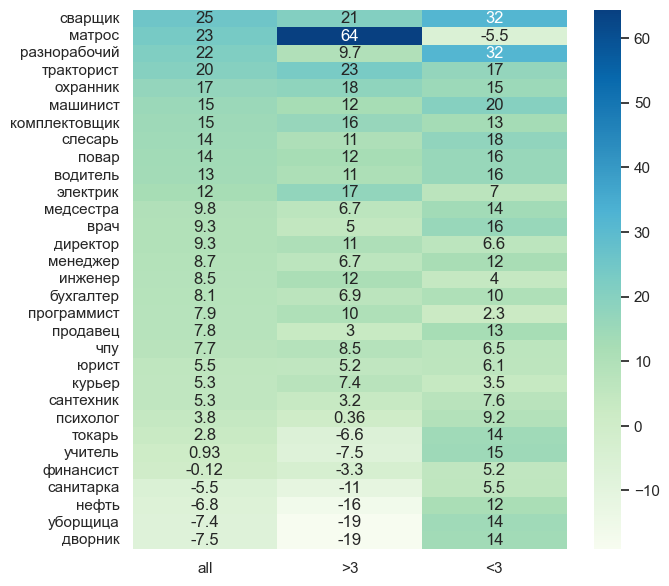

In [49]:
plt.figure(figsize=(7,7))
sns.set(font_scale=1.0)
sns.heatmap(df,cmap='GnBu',annot=True)

In [50]:
df = pd.DataFrame({"change": change1}).rank()
df = pd.merge(df, mean1.mean().rank().rename("mean"), left_index=True, right_index=True)
df["sum_rank"] = df["change"] + df["mean"]
df = df.sort_values(by="sum_rank", ascending=False)

<Axes: >

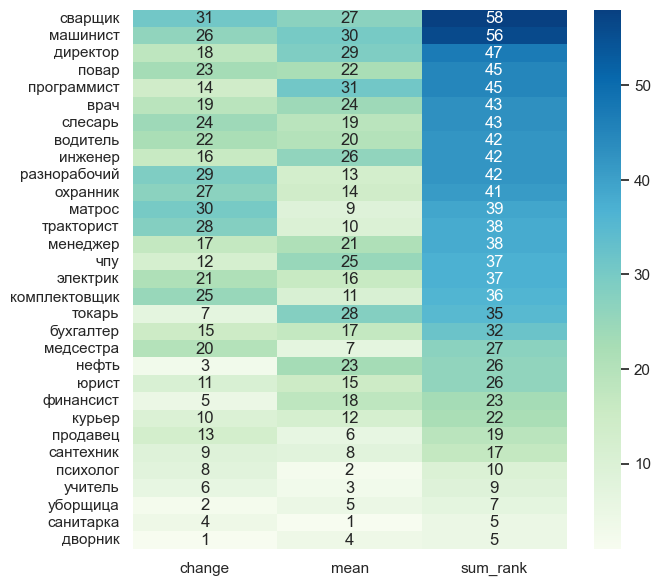

In [51]:
plt.figure(figsize=(7,7))
sns.set(font_scale=1.0)
sns.heatmap(df,cmap='GnBu',annot=True)